In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
import joblib
from sklearn.decomposition import PCA


In [6]:
X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv")
print(f"Ready for clustering with {X_train_scaled.shape[1]} features.")

Ready for clustering with 15 features.


In [14]:
X_train_scaled.isnull().sum()  # to check for null values

gender                            0
age                               0
hypertension                      0
heart_disease                     0
ever_married                      0
Residence_type                    0
avg_glucose_level                 0
bmi                               0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
Cluster                           0
dtype: int64

In [24]:
X_train_scaled.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Cluster
0,1,1.042906,0,0,1,1,2.188080,-0.146018,False,True,False,False,True,False,False,1
1,1,-0.815849,0,0,1,1,-0.700822,-0.632057,False,True,False,False,False,True,False,3
2,0,0.634886,1,1,0,1,-0.835780,1.312098,False,False,True,False,False,True,False,0
3,1,-0.951855,0,1,1,1,-0.213768,-0.146018,False,True,False,False,True,False,False,0
4,0,0.725557,0,0,1,1,2.324225,1.630537,False,False,False,False,False,True,False,1


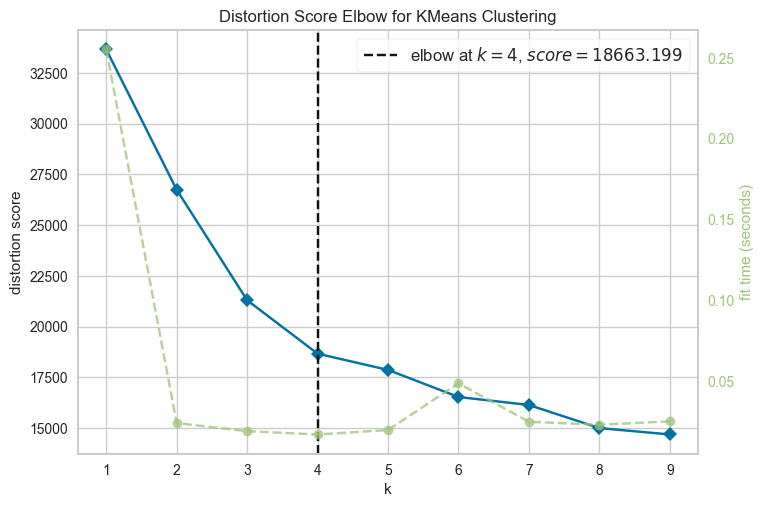

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [8]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,10))

visualizer.fit(X_train_scaled)    # The elbow method helps us to find the value of k so that we can cluster accordingly .
visualizer.poof()    

In [20]:
k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)
df.head().T

,0,1,2,3,4
gender,1,1,0,1,0
age,1.042906,-0.815849,0.634886,-0.951855,0.725557
hypertension,0,0,1,0,0
heart_disease,0,0,1,1,0
ever_married,1,1,0,1,1
Residence_type,1,1,1,1,1
avg_glucose_level,2.18808,-0.700822,-0.83578,-0.213768,2.324225
bmi,-0.146018,-0.632057,1.312098,-0.146018,1.630537
work_type_Never_worked,False,False,False,False,False
work_type_Private,True,True,False,True,False


In [48]:
print("Cluster Distribution:")
print(X_train["Cluster"].value_counts().sort_index())

# optional percentage view
print("\nPercentage distribution:")
print(X_train["Cluster"].value_counts(normalize=True).sort_index() * 100)

Cluster Distribution:
Cluster
0    1537
1    2532
2    1154
3    1583
Name: count, dtype: int64

Percentage distribution:
Cluster
0    22.583015
1    37.202468
2    16.955627
3    23.258889
Name: proportion, dtype: float64


The cluster distribution shows that cluster 1 contains the highest proportion of patients with a percentage of 37.2% indicating a dominant health profile in the dataset . The remaining clusters are more evenly distributed , representing a distinct subgroups with diffirent health characteristics.

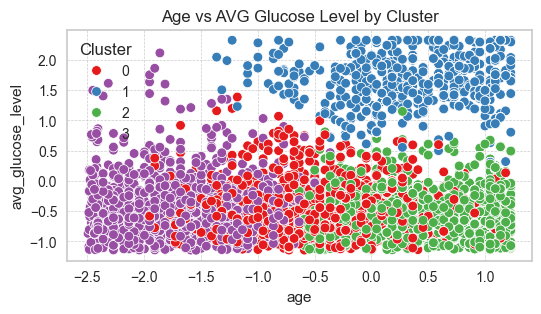

In [49]:
plt.figure(figsize=(6, 3))

sns.scatterplot(
    data=X_train_scaled,
    x="age",
    y="avg_glucose_level",
    hue="Cluster",
    palette="Set1"
)

plt.xlabel("age")
plt.ylabel("avg_glucose_level")
plt.title("Age vs AVG Glucose Level by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

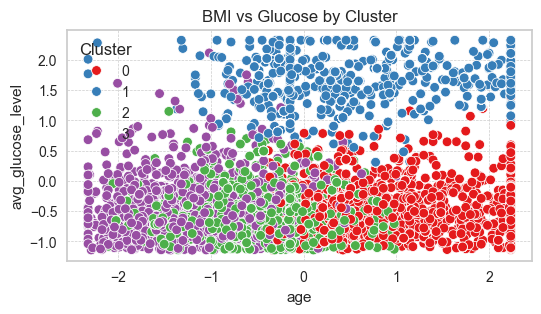

In [22]:
plt.figure(figsize=(6, 3))

sns.scatterplot(
    data=X_train_scaled,
    x="bmi",
    y="avg_glucose_level",
    hue="Cluster",
    palette="Set1"
)

plt.xlabel("age")
plt.ylabel("avg_glucose_level")
plt.title("BMI vs Glucose by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

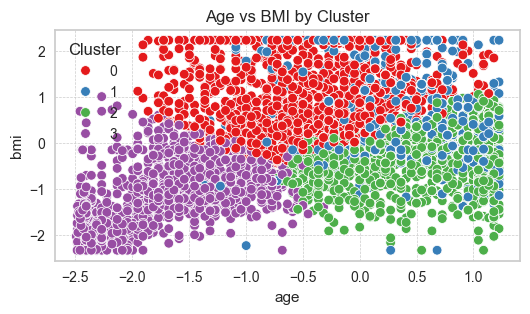

In [25]:
plt.figure(figsize=(6, 3))

sns.scatterplot(
    data=X_train_scaled,
    x="age",
    y="bmi",
    hue="Cluster",
    palette="Set1"
)

plt.xlabel("age")
plt.ylabel("bmi")
plt.title("Age vs BMI by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

Scatter Plot interpretation
The scatter plots illustrate hoe the K-Means algorithmn grouped patients based on similarities in their health characteristics . In the Age vs AVG Glucose Level and BMI vs AVG Glucose level plots , the clusters show clearer seperation mainly along the avg_glucose_level axis . This shows that glucose level is one of the strongest features influencing the clustering results . Patients with higher glucose values tend to fall into one dominant cluster , while patients with lower glucose are distributed among the remaining clusters . 

In contrants , The Age vs BMI scatter plots shows greater overlap between clusters , suggesting that age and BMI alone are not sufficient to clearly seperate patients into distinct groups . However , some visible grouping patterns still exist , where certain clusters contain younger patients with lower BMI values , while others contain older patients with moderate to higher BMI

Overall , the scatter plots suggest that avg_glucose_level contributes most strongly to cluster information , while age and BMI provide additional but weaker seperation , resulting in some overlap between clusters.

In [27]:
#To reduce it to two dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_train_scaled)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters

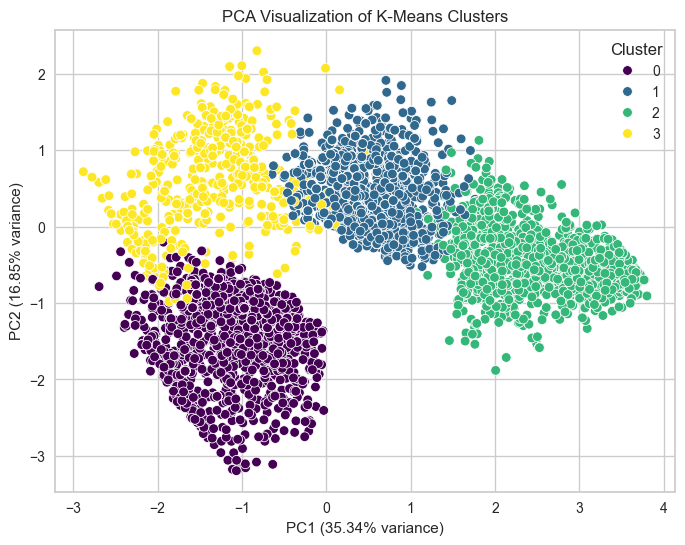

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis"
)

plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.show()

The PCA is applied to reduce the high-dimension into two main components (PC1 and PC2) for visualization purposes . PC1 explains 35.34 and PC2 explains 16.85 of the variance , giving a combined variance of approximately 52% meaning that they provide reasonable low dimensional representation of the data set . The PCA plot shows clear seperation between the four K-means clusters , indicating that the model sucessfully identified distinct patient groups .


In [32]:
cluster_profile = X_train_scaled.groupby("Cluster").mean(numeric_only=True)
display(cluster_profile)

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
Cluster,,,,,,,,,,,,,,,
0,0.436565,-0.358129,0.141835,0.052700,0.801561,0.538061,-0.476599,0.960761,0.000651,0.706571,0.126871,0.003904,0.191282,0.402733,0.234873
1,0.481364,0.537657,0.324068,0.263424,0.959570,0.512318,1.648708,0.436642,0.000000,0.610865,0.262160,0.000000,0.244473,0.397347,0.190145
2,0.364929,0.644877,0.163507,0.134281,0.903633,0.501185,-0.534831,-0.362540,0.000000,0.522117,0.333728,0.000000,0.282780,0.361769,0.133491
3,0.405546,-1.675474,0.002600,0.000000,0.171577,0.505199,-0.453361,-1.083138,0.009532,0.441941,0.058925,0.429809,0.084055,0.282496,0.089255


In [40]:
cluster_profile = X_train_scaled.groupby("Cluster").mean(numeric_only=True)
cluster_profile

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
Cluster,,,,,,,,,,,,,,,
0,0.436565,-0.358129,0.141835,0.052700,0.801561,0.538061,-0.476599,0.960761,0.000651,0.706571,0.126871,0.003904,0.191282,0.402733,0.234873
1,0.481364,0.537657,0.324068,0.263424,0.959570,0.512318,1.648708,0.436642,0.000000,0.610865,0.262160,0.000000,0.244473,0.397347,0.190145
2,0.364929,0.644877,0.163507,0.134281,0.903633,0.501185,-0.534831,-0.362540,0.000000,0.522117,0.333728,0.000000,0.282780,0.361769,0.133491
3,0.405546,-1.675474,0.002600,0.000000,0.171577,0.505199,-0.453361,-1.083138,0.009532,0.441941,0.058925,0.429809,0.084055,0.282496,0.089255
